# Evaluasi Model XGBoost pada Ambang F1 Terbaik

**Tanggal kegiatan: 19 Juli 2026**

Notebook ini merekam hasil evaluasi model pada **ambang F1 terbaik (0,705)**, yaitu
titik di mana presisi dan recall paling seimbang. Ini adalah pilihan ambang standar
yang dipakai bila tidak ada pertimbangan khusus.

Hasil di sini menjadi dasar keputusan revisi yang dilakukan pada awal Agustus 2026:
recall 0,493 dinilai terlalu rendah untuk alat skrining stroke, sehingga ambangnya
diturunkan. Perbandingan lengkap kedua ambang ada di
`xgboost_stroke_training.ipynb`.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
    average_precision_score,
)
import joblib

from model.train import (
    load_dataset, FEATURE_ORDER, RANDOM_STATE, CV,
    _ordinal_encode_for_xgb, best_f1_threshold,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("Pustaka siap.")

Pustaka siap.


## 1. Data dan Model

In [2]:
df = load_dataset()
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

art = joblib.load("artifacts/stroke_risk_model.joblib")
model = art["model"]
Xtr_e, Xte_e = _ordinal_encode_for_xgb(X_train), _ordinal_encode_for_xgb(X_test)

print(f"Data latih : {len(X_train):,} baris ({int(y_train.sum())} kasus stroke)")
print(f"Data uji   : {len(X_test):,} baris ({int(y_test.sum())} kasus stroke)")
print(f"Model      : {art['model_name']}")

Data latih : 3,577 baris (174 kasus stroke)
Data uji   : 1,533 baris (75 kasus stroke)
Model      : XGBClassifier


## 2. Ambang F1 Terbaik

Dicari dari prediksi out-of-fold pada data latih, bukan dari data uji, agar
ambangnya tidak ikut menyesuaikan jawaban.

In [3]:
oof = cross_val_predict(model, Xtr_e, y_train, cv=CV, method="predict_proba")[:, 1]
th_f1 = best_f1_threshold(y_train.to_numpy(), oof)

cand = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_train, (oof >= t).astype(int)) for t in cand]

print(f"Ambang bawaan          : 0.500")
print(f"Ambang F1 terbaik      : {th_f1:.3f}")
print(f"F1 pada ambang tersebut: {max(f1s):.4f}")
print()
print("Ambang bergeser di atas 0,5 karena fungsi loss model sudah dibobot ulang")
print("lewat scale_pos_weight, sehingga probabilitas keluarannya ikut naik.")

Ambang bawaan          : 0.500
Ambang F1 terbaik      : 0.705
F1 pada ambang tersebut: 0.2946

Ambang bergeser di atas 0,5 karena fungsi loss model sudah dibobot ulang
lewat scale_pos_weight, sehingga probabilitas keluarannya ikut naik.


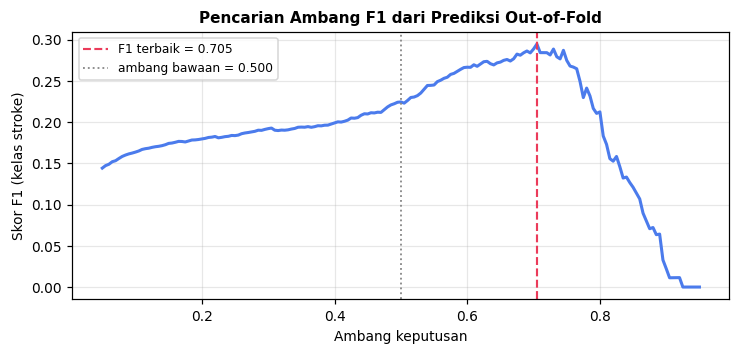

In [4]:
fig, ax = plt.subplots(figsize=(6.8, 3.3))
ax.plot(cand, f1s, lw=2, color="#4b7bec")
ax.axvline(th_f1, color="#eb3b5a", ls="--", lw=1.4, label=f"F1 terbaik = {th_f1:.3f}")
ax.axvline(0.5, color="#888", ls=":", lw=1.2, label="ambang bawaan = 0.500")
ax.set_xlabel("Ambang keputusan"); ax.set_ylabel("Skor F1 (kelas stroke)")
ax.set_title("Pencarian Ambang F1 dari Prediksi Out-of-Fold",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Evaluasi pada Data Uji

Data uji ini tidak pernah dilihat model, baik saat pelatihan maupun saat
penentuan ambang.

In [5]:
proba = model.predict_proba(Xte_e)[:, 1]
y_pred = (proba >= th_f1).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Ambang dipakai: {th_f1:.3f}")
print()
print("METRIK")
print(f"  Akurasi           : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, proba):.4f}")
print(f"  Average precision : {average_precision_score(y_test, proba):.4f}")
print(f"  Recall            : {recall_score(y_test, y_pred):.4f}")
print(f"  Presisi           : {precision_score(y_test, y_pred):.4f}")
print(f"  F1                : {f1_score(y_test, y_pred):.4f}")
print()
print("MATRIKS KONFUSI")
print(f"  Benar negatif  (TN) : {tn:5d}   sehat, ditandai sehat")
print(f"  Salah positif  (FP) : {fp:5d}   sehat, ditandai berisiko")
print(f"  Salah negatif  (FN) : {fn:5d}   penderita TERLEWAT")
print(f"  Benar positif  (TP) : {tp:5d}   penderita terdeteksi")
print()
print(f"Dari {tp+fn} penderita, {tp} terdeteksi ({100*tp/(tp+fn):.1f}%).")
print(f"Sebanyak {fn} penderita terlewat.")
print()
print(f"Salah positif {fp} dari {tn+fp} orang sehat ({100*fp/(tn+fp):.1f}%).")

Ambang dipakai: 0.705

METRIK
  Akurasi           : 0.8819
  ROC-AUC           : 0.8230
  Average precision : 0.2500
  Recall            : 0.4933
  Presisi           : 0.2056
  F1                : 0.2902

MATRIKS KONFUSI
  Benar negatif  (TN) :  1315   sehat, ditandai sehat
  Salah positif  (FP) :   143   sehat, ditandai berisiko
  Salah negatif  (FN) :    38   penderita TERLEWAT
  Benar positif  (TP) :    37   penderita terdeteksi

Dari 75 penderita, 37 terdeteksi (49.3%).
Sebanyak 38 penderita terlewat.

Salah positif 143 dari 1458 orang sehat (9.8%).


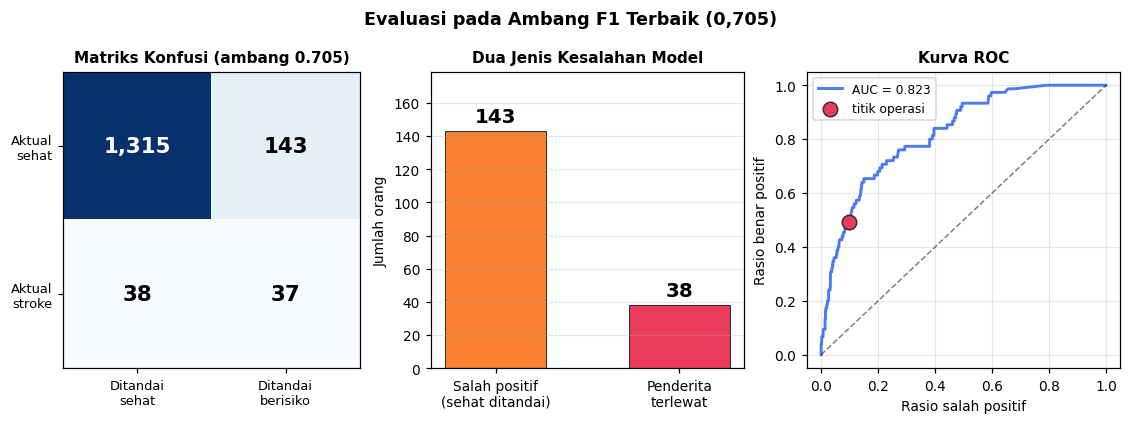

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.5))

im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1], ["Ditandai\nsehat", "Ditandai\nberisiko"], fontsize=8.5)
ax[0].set_yticks([0, 1], ["Aktual\nsehat", "Aktual\nstroke"], fontsize=8.5)
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=14,
                   fontweight="bold",
                   color="white" if cm[i, j] > cm.max()/2 else "black")
ax[0].set_title(f"Matriks Konfusi (ambang {th_f1:.3f})", fontsize=10, fontweight="bold")

# Salah positif lawan penderita terlewat
b = ax[1].bar(["Salah positif\n(sehat ditandai)", "Penderita\nterlewat"], [fp, fn],
              color=["#fa8231", "#eb3b5a"], edgecolor="#2d3436", linewidth=.7, width=.55)
ax[1].bar_label(b, fmt="%d", fontsize=13, fontweight="bold", padding=3)
ax[1].set_ylabel("Jumlah orang"); ax[1].set_ylim(0, max(fp, fn)*1.25)
ax[1].set_title("Dua Jenis Kesalahan Model", fontsize=10, fontweight="bold")
ax[1].grid(axis="y", alpha=.3)

fpr, tpr, _ = roc_curve(y_test, proba)
ax[2].plot(fpr, tpr, color="#4b7bec", lw=1.9,
           label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
ax[2].plot([0, 1], [0, 1], "k--", lw=1, alpha=.5)
ax[2].scatter([fp/(tn+fp)], [tp/(tp+fn)], s=90, color="#eb3b5a", zorder=5,
              edgecolor="#2d3436", label="titik operasi")
ax[2].set_xlabel("Rasio salah positif"); ax[2].set_ylabel("Rasio benar positif")
ax[2].set_title("Kurva ROC", fontsize=10, fontweight="bold")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

fig.suptitle("Evaluasi pada Ambang F1 Terbaik (0,705)",
             fontsize=11.5, fontweight="bold", y=1.04)
plt.show()

## 4. Catatan Evaluasi

Presisi 0,206 berarti dari 5 orang yang ditandai berisiko, sekitar 1 benar-benar
berisiko. Angka ini jauh lebih baik daripada bila ambangnya diturunkan.

Namun recall 0,493 berarti **lebih dari separuh penderita tidak terdeteksi**.
Untuk alat skrining stroke, ini yang menjadi persoalan: seseorang yang berisiko
tidak menerima peringatan apa pun, padahal keterlambatan penanganan stroke
berakibat disabilitas permanen atau kematian.

Ambang F1 memberi bobot yang sama pada dua jenis kesalahan: satu penderita
terlewat dianggap sama beratnya dengan satu orang sehat yang salah ditandai.
Pada kasus stroke, kedua kesalahan itu jelas tidak setara.

Temuan ini menjadi dasar revisi ambang yang dilakukan pada awal Agustus 2026.